# Panda pilot evaluation

This notebook contains the evaluation workflow for the Panda pilot experiment. The experiment evaluates the pretrained [Panda](https://github.com/abao1999/panda) forecasting model on matched single-scale and multiscale Lorenz–96 trajectories.

## 1. Setup

Run this notebook from the repository root with the `panda_pilot` Conda environment active. Create the environment, if needed, with:

```bash
conda env create --file environments/panda_pilot.yml
conda activate panda_pilot
```

In [12]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm.auto import tqdm

from src.models.baseline.panda import load_panda

In [13]:
project_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "src").is_dir() and (path / "data").is_dir()
)
target_data_root = project_root / "data" / "panda_pilot" / "lorenz96_target"
dense_data_root = project_root / "data" / "panda_pilot" / "lorenz96_dense"

target_data_root

PosixPath('/Users/yuhanzheng/PycharmProjects/MultiscaleDynamicsAI/data/panda_pilot/lorenz96_target')

## 2. Prepared data

Complete the data-preparation pipeline described in `README.md` before evaluation. The target datasets used below are organized by epsilon and seed:

```text
data/panda_pilot/lorenz96_target/
├── eps_2neg5/
│   ├── seed_0/
│   │   ├── simulation_data_multiscale.npz
│   │   └── simulation_data_singlescale.npz
│   └── ...
└── eps_2neg10/
    └── ...
```

## 3. Load Panda

Load the pretrained Panda checkpoint and record the exact checkpoint revision used for the experiment.

In [14]:
ckpt = "GilpinLab/panda"  # Original checkpoint (not the scaled-up panda-72M model).

if not torch.backends.mps.is_available():
    raise RuntimeError("This experiment requires a Mac GPU with PyTorch MPS support.")

panda = load_panda(
    mode="predict",
    checkpoint=ckpt,
    device_map="mps",
)
panda.model.eval()

print(f"Loaded {ckpt} on {panda.device}")

/opt/homebrew/Caskroom/miniconda/base/envs/panda_pilot/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loaded GilpinLab/panda on mps:0


## 4. Evaluation

### 4.1 Representative Lorenz–96 trajectories

Before forecasting, visualize the matched single-scale and multiscale trajectories for $\epsilon=2^{-7}$ and seed 0. The line plots show three representative channels over five characteristic slow periods. The heatmap retains all 72 fast variables while preserving their grouping into eight fast variables for each slow variable.

In [15]:
epsilon_name = "eps_2neg7"
seed = 0
K, J = 9, 8
periods_to_plot = 5

target_dir = target_data_root / epsilon_name / f"seed_{seed}"
metadata_dir = dense_data_root / epsilon_name / f"seed_{seed}"

with np.load(target_dir / "simulation_data_singlescale.npz") as data:
    single_states = data["states"].copy()

with np.load(target_dir / "simulation_data_multiscale.npz") as data:
    multiscale_states = data["states"].copy()

with open(metadata_dir / "sampling_interval_singlescale.json") as file:
    single_metadata = json.load(file)

with open(metadata_dir / "sampling_interval_multiscale.json") as file:
    multiscale_metadata = json.load(file)

multiscale_slow = multiscale_states[:K]
multiscale_fast = multiscale_states[K:].reshape(K, J, -1)

assert single_states.shape == (K, 4096)
assert multiscale_states.shape == (K + K * J, 4096)

single_time = (
    np.arange(single_states.shape[1])
    * single_metadata["target_sampling_interval"]
    / single_metadata["characteristic_period"]
)
multiscale_time = (
    np.arange(multiscale_states.shape[1])
    * multiscale_metadata["target_sampling_interval"]
    / multiscale_metadata["characteristic_period"]
)

single_window = single_time <= periods_to_plot
multiscale_window = multiscale_time <= periods_to_plot

print(f"Single-scale states: {single_states.shape}")
print(f"Multiscale slow states: {multiscale_slow.shape}")
print(f"Multiscale fast states: {multiscale_fast.shape}")

Single-scale states: (9, 4096)
Multiscale slow states: (9, 4096)
Multiscale fast states: (9, 8, 4096)


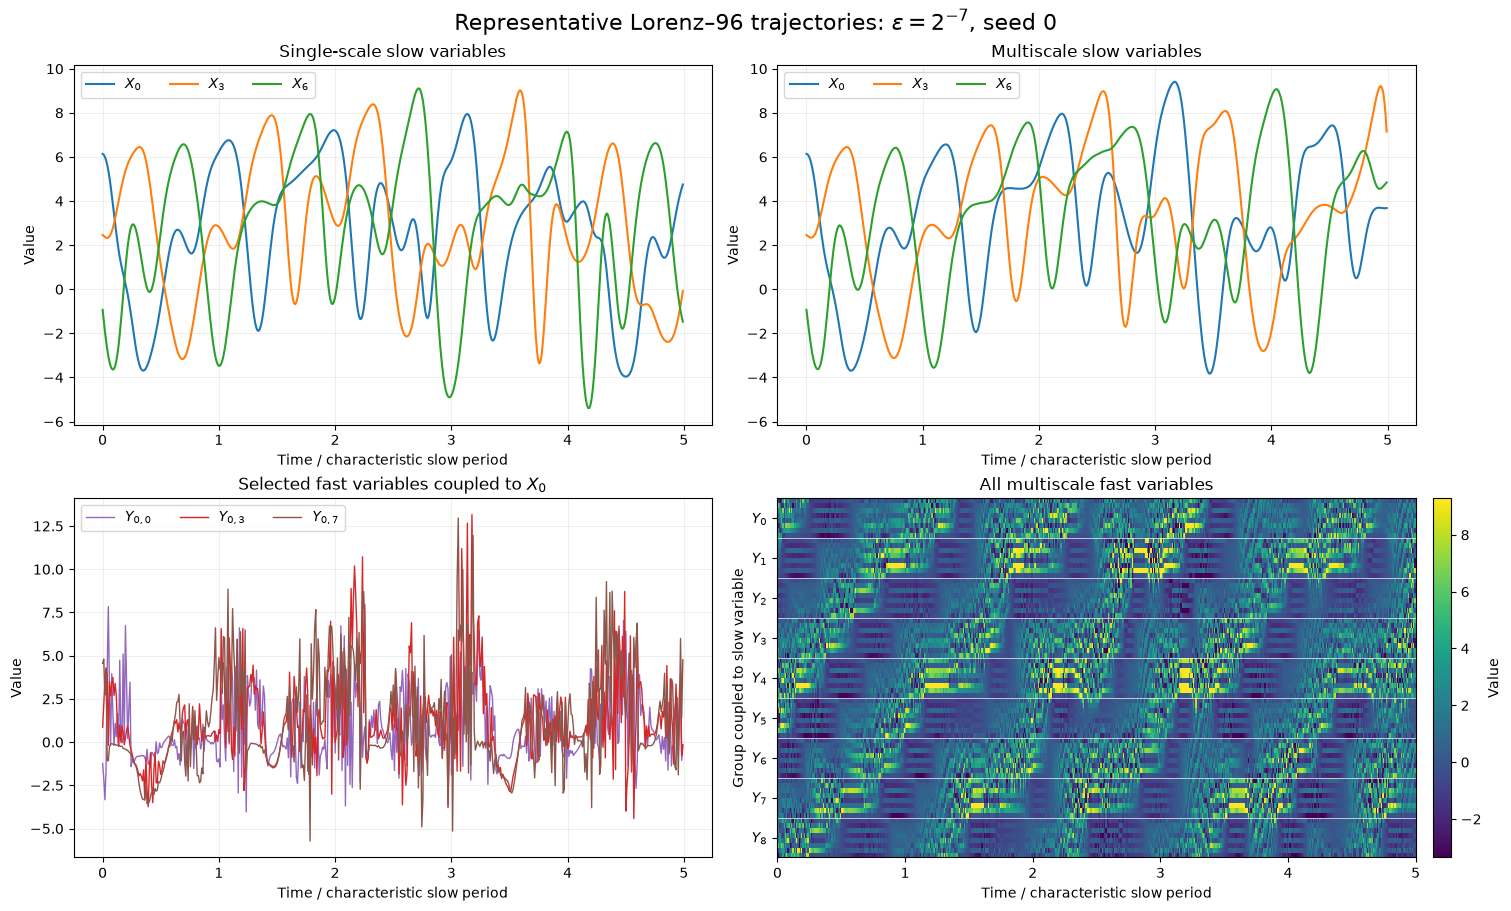

In [16]:
slow_indices = [0, 3, 6]
fast_indices = [0, 3, 7]
slow_colors = ["tab:blue", "tab:orange", "tab:green"]
fast_colors = ["tab:purple", "tab:red", "tab:brown"]

fig, axes = plt.subplots(2, 2, figsize=(15, 9), constrained_layout=True)

for index, color in zip(slow_indices, slow_colors):
    axes[0, 0].plot(
        single_time[single_window],
        single_states[index, single_window],
        color=color,
        label=rf"$X_{{{index}}}$",
    )
    axes[0, 1].plot(
        multiscale_time[multiscale_window],
        multiscale_slow[index, multiscale_window],
        color=color,
        label=rf"$X_{{{index}}}$",
    )

slow_limits = np.concatenate([
    single_states[slow_indices][:, single_window].ravel(),
    multiscale_slow[slow_indices][:, multiscale_window].ravel(),
])
slow_margin = 0.05 * np.ptp(slow_limits)

for axis, title in zip(
    axes[0],
    ["Single-scale slow variables", "Multiscale slow variables"],
):
    axis.set(ylim=(slow_limits.min() - slow_margin, slow_limits.max() + slow_margin))
    axis.set_title(title)
    axis.set_xlabel("Time / characteristic slow period")
    axis.set_ylabel("Value")
    axis.legend(ncols=3)
    axis.grid(alpha=0.2)

for index, color in zip(fast_indices, fast_colors):
    axes[1, 0].plot(
        multiscale_time[multiscale_window],
        multiscale_fast[0, index, multiscale_window],
        color=color,
        linewidth=1.0,
        label=rf"$Y_{{0,{index}}}$",
    )

axes[1, 0].set_title(r"Selected fast variables coupled to $X_0$")
axes[1, 0].set_xlabel("Time / characteristic slow period")
axes[1, 0].set_ylabel("Value")
axes[1, 0].legend(ncols=3)
axes[1, 0].grid(alpha=0.2)

fast_window = multiscale_fast[:, :, multiscale_window].reshape(K * J, -1)
vmin, vmax = np.quantile(fast_window, [0.01, 0.99])
image = axes[1, 1].imshow(
    fast_window,
    aspect="auto",
    interpolation="nearest",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
    extent=(0, periods_to_plot, K * J - 0.5, -0.5),
)
for boundary in range(J, K * J, J):
    axes[1, 1].axhline(boundary - 0.5, color="white", linewidth=0.6, alpha=0.8)

axes[1, 1].set_yticks(np.arange(J / 2 - 0.5, K * J, J), [rf"$Y_{k}$" for k in range(K)])
axes[1, 1].set_title("All multiscale fast variables")
axes[1, 1].set_xlabel("Time / characteristic slow period")
axes[1, 1].set_ylabel("Group coupled to slow variable")
fig.colorbar(image, ax=axes[1, 1], label="Value", pad=0.02)

fig.suptitle(r"Representative Lorenz–96 trajectories: $\epsilon=2^{-7}$, seed 0", fontsize=16)
plt.show()

### 4.2 Reference-system validation

Validate the checkpoint on two three-dimensional systems using the protocol in the PANDA paper: a context of 512 samples, a forecast of 128 samples, and six evenly spaced windows from each 4,096-point trajectory. Lorenz–63 is represented in PANDA's released `base40` training split. QiChen is the held-out zero-shot example used by the upstream `load_model_from_hf.ipynb` notebook. Only pointwise relative $L_2$ error is computed here.

In [22]:
benchmark_paths = {
    "Lorenz–63 (training)": project_root / "data/panda_pilot/panda_lorenz63/trajectory.npz",
    "QiChen (held out)": project_root / "data/panda_pilot/panda_qichen/trajectory.npz",
}

benchmark_states = {}
benchmark_times = {}
for name, path in benchmark_paths.items():
    with np.load(path) as data:
        benchmark_states[name] = data["states"].copy()
        benchmark_times[name] = data["time"].copy()

CONTEXT_LENGTH = 512
PREDICTION_LENGTH = 128

def panda_forecast(states, start, prediction_length):
    """Forecast a channel-first trajectory and return a channel-first array."""
    context = states[:, start : start + CONTEXT_LENGTH].T
    context_tensor = torch.as_tensor(context, dtype=torch.float32)
    samples = panda.predict(
        context_tensor,
        prediction_length,
        limit_prediction_length=False,
        sliding_context=True,
        verbose=False,
    )
    return samples.median(dim=1).values[0].T.cpu().numpy()

def relative_l2_by_lead(prediction, target):
    """Compute ||prediction-target||_2 / ||target||_2 across channels."""
    numerator = np.linalg.norm(prediction - target, axis=0)
    denominator = np.linalg.norm(target, axis=0)
    return numerator / np.maximum(denominator, np.finfo(float).eps)

def evaluate_forecast_windows(states, num_windows=6, prediction_length=PREDICTION_LENGTH):
    last_start = states.shape[1] - CONTEXT_LENGTH - prediction_length
    starts = np.linspace(0, last_start, num_windows, dtype=int)
    predictions, errors = [], []
    for start in tqdm(starts, desc="Forecast windows", leave=False):
        prediction = panda_forecast(states, start, prediction_length)
        target_start = start + CONTEXT_LENGTH
        target = states[:, target_start : target_start + prediction_length]
        predictions.append(prediction)
        errors.append(relative_l2_by_lead(prediction, target))
    return {
        "starts": starts,
        "predictions": np.stack(predictions),
        "relative_l2": np.stack(errors),
    }

In [18]:
benchmark_results = {}
for name, states in benchmark_states.items():
    print(f"Evaluating {name}")
    benchmark_results[name] = evaluate_forecast_windows(states)

Evaluating Lorenz–63 (training)


Evaluating QiChen (held out)


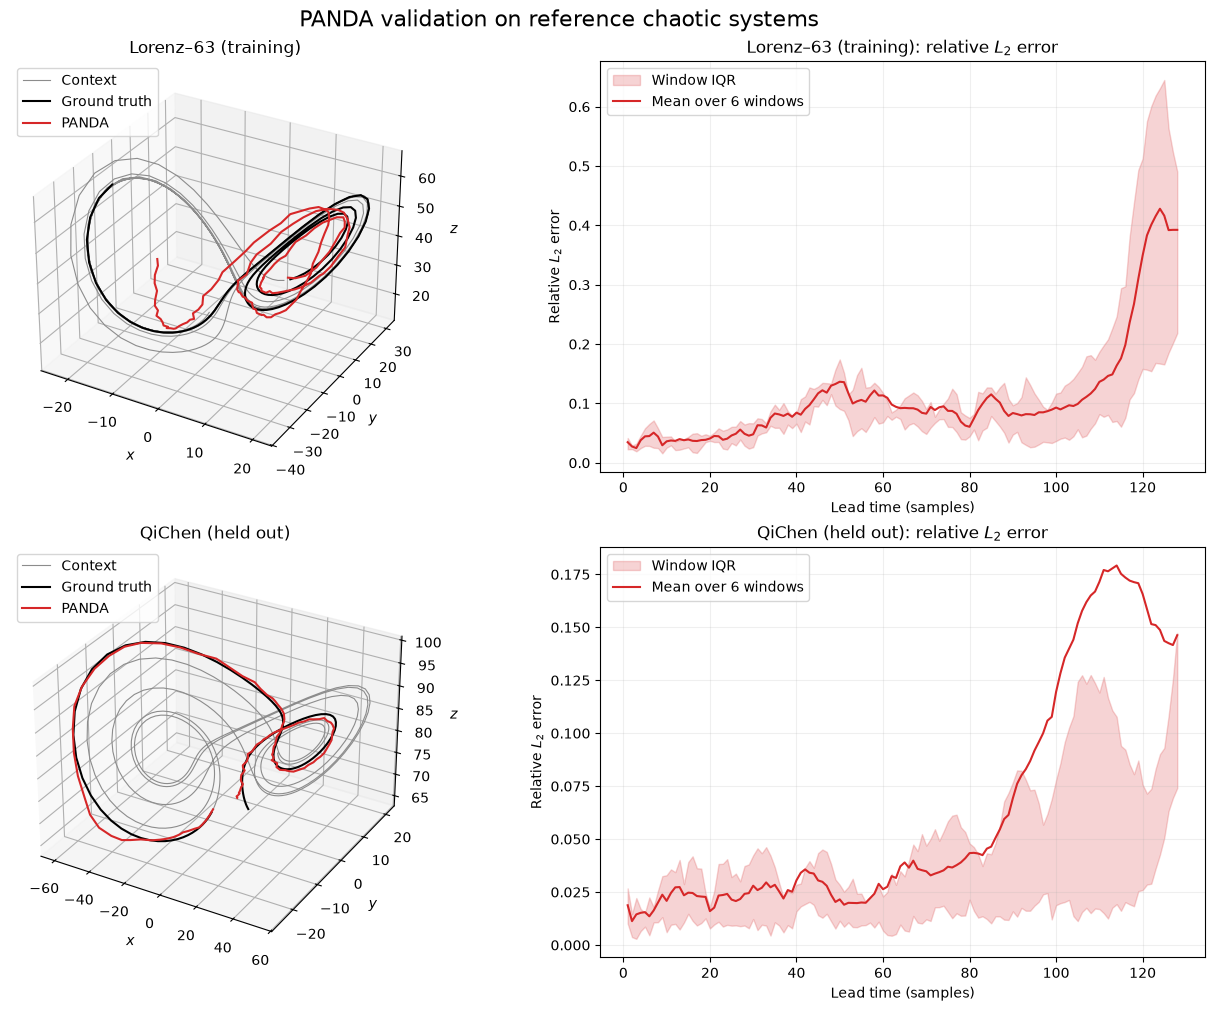

In [19]:
fig = plt.figure(figsize=(13, 10), constrained_layout=True)
grid = fig.add_gridspec(len(benchmark_states), 2)

for row, (name, states) in enumerate(benchmark_states.items()):
    result = benchmark_results[name]
    start = int(result["starts"][0])
    target_start = start + CONTEXT_LENGTH
    context = states[:, start:target_start]
    target = states[:, target_start : target_start + PREDICTION_LENGTH]
    prediction = result["predictions"][0]

    attractor_axis = fig.add_subplot(grid[row, 0], projection="3d")
    attractor_axis.plot(*context, color="0.55", linewidth=0.8, label="Context")
    attractor_axis.plot(*target, color="black", linewidth=1.5, label="Ground truth")
    attractor_axis.plot(*prediction, color="tab:red", linewidth=1.5, label="PANDA")
    attractor_axis.set_title(name)
    attractor_axis.set_xlabel("$x$")
    attractor_axis.set_ylabel("$y$")
    attractor_axis.set_zlabel("$z$")
    attractor_axis.legend(loc="upper left")

    error_axis = fig.add_subplot(grid[row, 1])
    errors = result["relative_l2"]
    lead = np.arange(1, errors.shape[1] + 1)
    lower, upper = np.quantile(errors, [0.25, 0.75], axis=0)
    error_axis.fill_between(lead, lower, upper, color="tab:red", alpha=0.2, label="Window IQR")
    error_axis.plot(lead, errors.mean(axis=0), color="tab:red", label="Mean over 6 windows")
    error_axis.set_title(f"{name}: relative $L_2$ error")
    error_axis.set_xlabel("Lead time (samples)")
    error_axis.set_ylabel("Relative $L_2$ error")
    error_axis.grid(alpha=0.2)
    error_axis.legend()

fig.suptitle("PANDA validation on reference chaotic systems", fontsize=16)
plt.show()

### 4.3 One-window Lorenz–96 forecast

Use the same setting as the Lorenz–63 and QiChen validation: 512 context samples followed by one 128-sample prediction. For both the single-scale and multiscale datasets, PANDA receives and predicts only the nine slow variables. Relative $L_2$ error is averaged over the 32 seeds, while the three-dimensional trajectory plot shows $X_0$, $X_3$, and $X_6$ for seed 0. Single-scale and multiscale results are shown in separate figures.

In [25]:
l96_epsilon = "eps_2neg7"
l96_short_horizon = 128
l96_cache_root = project_root / "data/panda_pilot/panda_rollout_cache"
l96_cache_root.mkdir(parents=True, exist_ok=True)

def evaluate_l96_short_forecast(variant, force_recompute=False):
    device_label = str(panda.device).replace(":", "_")
    cache_path = l96_cache_root / f"{l96_epsilon}_{variant}_slow9_short128_{device_label}.npz"
    if cache_path.exists() and not force_recompute:
        with np.load(cache_path) as cached:
            return {key: cached[key].copy() for key in cached.files}

    all_errors = []
    representative = {}
    for seed in tqdm(range(32), desc=f"L96 {variant}, 128 steps"):
        path = (
            target_data_root
            / l96_epsilon
            / f"seed_{seed}"
            / f"simulation_data_{variant}.npz"
        )
        with np.load(path) as data:
            states = data["states"][:K].copy()

        prediction = panda_forecast(states, start=0, prediction_length=l96_short_horizon)
        target = states[:, CONTEXT_LENGTH : CONTEXT_LENGTH + l96_short_horizon]
        all_errors.append(relative_l2_by_lead(prediction, target))

        if seed == 0:
            representative = {
                "context": states[:, :CONTEXT_LENGTH],
                "target": target,
                "prediction": prediction,
            }

    result = {"relative_l2": np.stack(all_errors), **representative}
    np.savez(cache_path, **result)
    return result

single_short = evaluate_l96_short_forecast("singlescale")
multiscale_short = evaluate_l96_short_forecast("multiscale")

L96 multiscale, 128 steps: 100%|██████████| 32/32 [00:00<00:00, 85.18it/s]


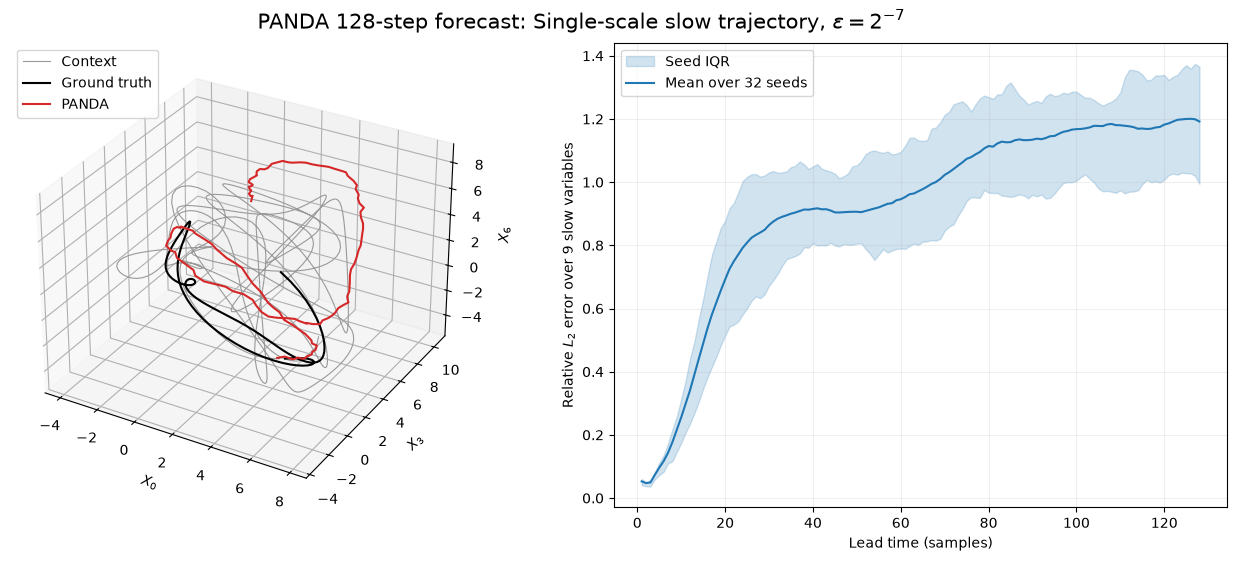

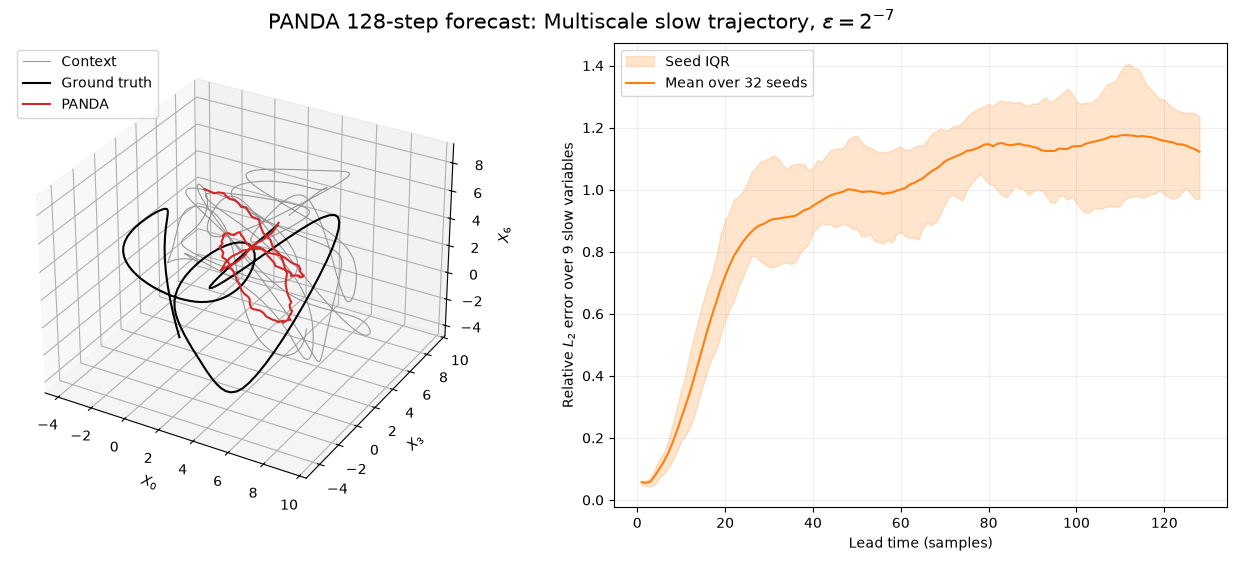

In [26]:
selected_slow = [0, 3, 6]
short_lead = np.arange(1, l96_short_horizon + 1)

for title, result, color in [
    ("Single-scale slow trajectory", single_short, "tab:blue"),
    ("Multiscale slow trajectory", multiscale_short, "tab:orange"),
]:
    fig = plt.figure(figsize=(13, 5.5), constrained_layout=True)
    grid = fig.add_gridspec(1, 2)

    trajectory_axis = fig.add_subplot(grid[0, 0], projection="3d")
    trajectory_axis.plot(*result["context"][selected_slow], color="0.6", linewidth=0.8, label="Context")
    trajectory_axis.plot(*result["target"][selected_slow], color="black", linewidth=1.5, label="Ground truth")
    trajectory_axis.plot(*result["prediction"][selected_slow], color="tab:red", linewidth=1.5, label="PANDA")
    trajectory_axis.set_xlabel("$X_0$")
    trajectory_axis.set_ylabel("$X_3$")
    trajectory_axis.set_zlabel("$X_6$")
    trajectory_axis.legend(loc="upper left")

    error_axis = fig.add_subplot(grid[0, 1])
    errors = result["relative_l2"]
    lower, upper = np.quantile(errors, [0.25, 0.75], axis=0)
    error_axis.fill_between(short_lead, lower, upper, color=color, alpha=0.2, label="Seed IQR")
    error_axis.plot(short_lead, errors.mean(axis=0), color=color, label="Mean over 32 seeds")
    error_axis.set_xlabel("Lead time (samples)")
    error_axis.set_ylabel("Relative $L_2$ error over 9 slow variables")
    error_axis.grid(alpha=0.2)
    error_axis.legend()

    fig.suptitle(rf"PANDA 128-step forecast: {title}, $\epsilon=2^{{-7}}$", fontsize=15)
    plt.show()

### 4.4 Long autoregressive rollout on Lorenz–96

For each of the 32 seeds at $\epsilon=2^{-7}$, give PANDA only the nine observed slow variables. Use samples 0–511 as context and autoregressively forecast slow-variable samples 512–4095. This is a 3,584-step rollout, or 28 successive 128-step PANDA forecasts, matching the longest rollout reported in the paper. The single-scale and multiscale experiments therefore have identical input and output dimensions; they differ only in the dynamics that generated their slow trajectories. Errors are cached after each system variant.

In [27]:
rollout_epsilon = "eps_2neg7"
rollout_horizon = 4096 - CONTEXT_LENGTH
rollout_cache_root = project_root / "data/panda_pilot/panda_rollout_cache"
rollout_cache_root.mkdir(parents=True, exist_ok=True)

def evaluate_l96_rollout(variant, force_recompute=False):
    device_label = str(panda.device).replace(":", "_")
    cache_path = rollout_cache_root / f"{rollout_epsilon}_{variant}_slow9_{device_label}_relative_l2.npz"
    if cache_path.exists() and not force_recompute:
        with np.load(cache_path) as cached:
            return {key: cached[key].copy() for key in cached.files}

    all_errors = []
    representative = {}
    for seed in tqdm(range(32), desc=f"L96 {variant}"):
        path = (
            target_data_root
            / rollout_epsilon
            / f"seed_{seed}"
            / f"simulation_data_{variant}.npz"
        )
        with np.load(path) as data:
            states = data["states"][:K].copy()

        prediction = panda_forecast(states, start=0, prediction_length=rollout_horizon)
        target = states[:, CONTEXT_LENGTH:]
        all_errors.append(relative_l2_by_lead(prediction, target))

        if seed == 0:
            representative = {
                "context": states[:, :CONTEXT_LENGTH],
                "target": target,
                "prediction": prediction,
            }

    result = {"relative_l2": np.stack(all_errors), **representative}
    np.savez(cache_path, **result)
    return result

single_rollout = evaluate_l96_rollout("singlescale")
multiscale_rollout = evaluate_l96_rollout("multiscale")

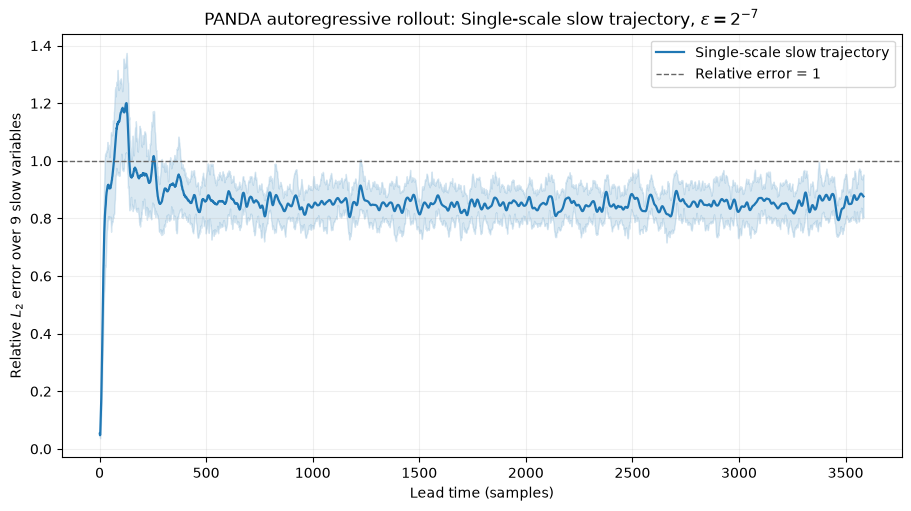

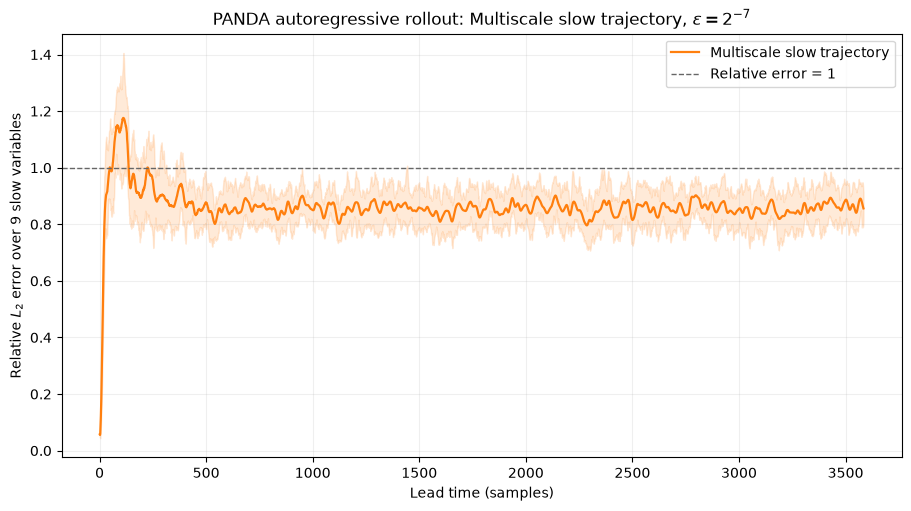

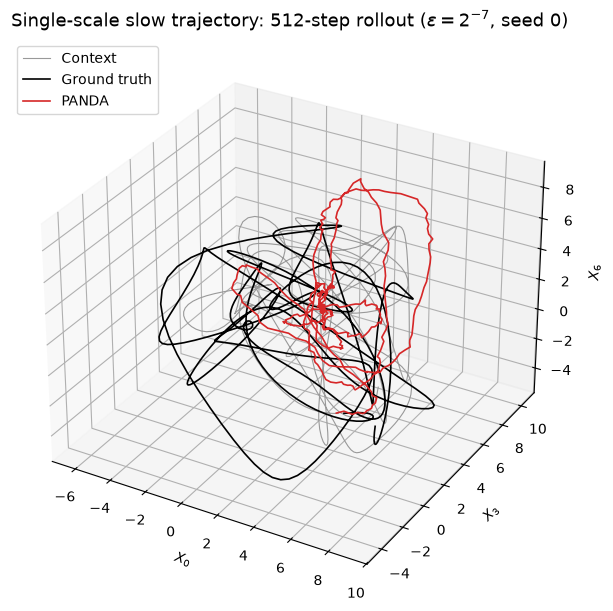

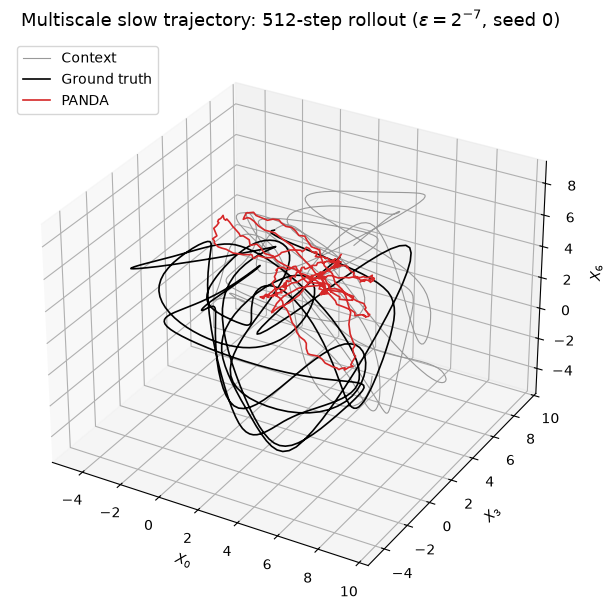

In [28]:
lead_samples = np.arange(1, rollout_horizon + 1)

def plot_seed_summary(axis, errors, label, color):
    mean = np.nanmean(errors, axis=0)
    lower, upper = np.nanquantile(errors, [0.25, 0.75], axis=0)
    axis.fill_between(lead_samples, lower, upper, color=color, alpha=0.16)
    axis.plot(lead_samples, mean, color=color, linewidth=1.6, label=label)

for title, result, color in [
    ("Single-scale slow trajectory", single_rollout, "tab:blue"),
    ("Multiscale slow trajectory", multiscale_rollout, "tab:orange"),
]:
    fig, axis = plt.subplots(figsize=(9, 5), constrained_layout=True)
    plot_seed_summary(axis, result["relative_l2"], title, color)
    axis.axhline(1.0, color="0.4", linestyle="--", linewidth=1.0, label="Relative error = 1")
    axis.set_title(rf"PANDA autoregressive rollout: {title}, $\epsilon=2^{{-7}}$")
    axis.set_xlabel("Lead time (samples)")
    axis.set_ylabel("Relative $L_2$ error over 9 slow variables")
    axis.grid(alpha=0.2)
    axis.legend()
    plt.show()

selected_slow = [0, 3, 6]
trajectory_plot_length = 512
for title, result in [
    ("Single-scale slow trajectory", single_rollout),
    ("Multiscale slow trajectory", multiscale_rollout),
]:
    fig = plt.figure(figsize=(7, 6), constrained_layout=True)
    trajectory_axis = fig.add_subplot(1, 1, 1, projection="3d")
    trajectory_axis.plot(*result["context"][selected_slow], color="0.6", linewidth=0.8, label="Context")
    trajectory_axis.plot(
        *result["target"][selected_slow, :trajectory_plot_length],
        color="black",
        linewidth=1.2,
        label="Ground truth",
    )
    trajectory_axis.plot(
        *result["prediction"][selected_slow, :trajectory_plot_length],
        color="tab:red",
        linewidth=1.2,
        label="PANDA",
    )
    trajectory_axis.set_xlabel("$X_0$")
    trajectory_axis.set_ylabel("$X_3$")
    trajectory_axis.set_zlabel("$X_6$")
    trajectory_axis.legend(loc="upper left")
    fig.suptitle(rf"{title}: 512-step rollout ($\epsilon=2^{{-7}}$, seed 0)", fontsize=13)
    plt.show()

## 5. Results

TODO: Aggregate the evaluation metrics and add the tables and figures used to interpret the Panda pilot results.